# Feature Engineering - Khoa

Notebook nay da duoc sua theo dung yeu cau moi:
- Dataset moi o dinh dang `parquet`
- `Time_Delta` da duoc them san o preprocessing, notebook khong tu tao lai nua
- `selected_features_list.txt` se ghi them nguong giu lai (`threshold`) cua tung dataset
- Selection van dung trung binh importance cua 4 model cay `DT`, `RF`, `ET`, `XGB`

Output chinh cho moi dataset:
- `X_train_selected.csv`
- `X_test_selected.csv`
- `selected_features_list.txt`


In [1]:
from __future__ import annotations

import math
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from scipy.stats import pearsonr
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.tree import DecisionTreeClassifier

print('xgboost version:', xgb.__version__)


@dataclass
class DatasetBundle:
    name: str
    x_train: pd.DataFrame
    y_train: pd.Series
    x_test: pd.DataFrame
    y_test: pd.Series


def read_x_parquet(path: str | Path) -> pd.DataFrame:
    df = pd.read_parquet(path)
    df.columns = [str(c) for c in df.columns]
    if 'TimeDelta' in df.columns and 'Time_Delta' not in df.columns:
        df = df.rename(columns={'TimeDelta': 'Time_Delta'})
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').astype('float32')
    return df.replace([np.inf, -np.inf], np.nan).fillna(0.0)


def read_y_parquet(path: str | Path) -> pd.Series:
    y_df = pd.read_parquet(path)
    if 'Label' in y_df.columns:
        y = y_df['Label']
    else:
        y = y_df.iloc[:, 0]
    return pd.to_numeric(y, errors='coerce').fillna(0).astype(int)


def align_xy(x: pd.DataFrame, y: pd.Series) -> Tuple[pd.DataFrame, pd.Series]:
    size = min(len(x), len(y))
    return x.iloc[:size].copy(), y.iloc[:size].copy()


def load_dataset(name: str, x_train_path: str, y_train_path: str, x_test_path: str, y_test_path: str) -> DatasetBundle:
    x_train = read_x_parquet(x_train_path)
    y_train = read_y_parquet(y_train_path)
    x_test = read_x_parquet(x_test_path)
    y_test = read_y_parquet(y_test_path)

    x_train, y_train = align_xy(x_train, y_train)
    x_test, y_test = align_xy(x_test, y_test)

    return DatasetBundle(name=name, x_train=x_train, y_train=y_train, x_test=x_test, y_test=y_test)


def describe_bundle(bundle: DatasetBundle) -> pd.DataFrame:
    summary = [
        ('dataset', bundle.name),
        ('x_train_shape', str(bundle.x_train.shape)),
        ('y_train_shape', str(bundle.y_train.shape)),
        ('x_test_shape', str(bundle.x_test.shape)),
        ('y_test_shape', str(bundle.y_test.shape)),
        ('same_columns', list(bundle.x_train.columns) == list(bundle.x_test.columns)),
        ('num_features', bundle.x_train.shape[1]),
        ('num_classes', int(bundle.y_train.nunique())),
    ]
    return pd.DataFrame(summary, columns=['item', 'value'])


def train_tree_models(x_train: pd.DataFrame, y_train: pd.Series, random_state: int = 42) -> Dict[str, object]:
    num_classes = int(pd.Series(y_train).nunique())

    xgb_params = {
        'n_estimators': 200,
        'max_depth': 8,
        'random_state': random_state,
        'n_jobs': -1,
        'tree_method': 'hist',
    }
    if num_classes > 2:
        xgb_params.update({
            'objective': 'multi:softprob',
            'num_class': num_classes,
            'eval_metric': 'mlogloss',
        })
    else:
        xgb_params.update({
            'objective': 'binary:logistic',
            'eval_metric': 'logloss',
        })

    models = {
        'DT': DecisionTreeClassifier(
            criterion='gini',
            max_depth=8,
            min_samples_split=8,
            min_samples_leaf=3,
            random_state=random_state,
        ),
        'RF': RandomForestClassifier(
            n_estimators=200,
            criterion='gini',
            max_depth=8,
            min_samples_split=8,
            min_samples_leaf=3,
            random_state=random_state,
            n_jobs=-1,
        ),
        'ET': ExtraTreesClassifier(
            n_estimators=200,
            criterion='gini',
            max_depth=8,
            min_samples_split=8,
            min_samples_leaf=3,
            random_state=random_state,
            n_jobs=-1,
        ),
        'XGB': xgb.XGBClassifier(**xgb_params),
    }

    trained = {}
    for name, model in models.items():
        print(f'Training {name} ...')
        model.fit(x_train, y_train)
        trained[name] = model
    return trained


def compute_average_importance(models: Dict[str, object], feature_names: Sequence[str]) -> pd.DataFrame:
    importance_df = pd.DataFrame(index=list(feature_names))
    for name, model in models.items():
        importance_df[name] = model.feature_importances_

    for col in importance_df.columns:
        total = float(importance_df[col].sum())
        if total > 0:
            importance_df[col] = importance_df[col] / total

    importance_df['avg_importance'] = importance_df.mean(axis=1)
    importance_df = importance_df.sort_values('avg_importance', ascending=False)
    importance_df['cumulative'] = importance_df['avg_importance'].cumsum()
    return importance_df


def select_features_by_threshold(importance_df: pd.DataFrame, threshold: float = 0.9) -> List[str]:
    selected = importance_df[importance_df['cumulative'] <= threshold].index.tolist()
    if not selected and len(importance_df) > 0:
        selected = [importance_df.index[0]]
    elif len(selected) < len(importance_df):
        selected.append(importance_df.index[len(selected)])
    return [str(c) for c in selected]


def map_selected_features(x_train: pd.DataFrame, x_test: pd.DataFrame, selected_features: Sequence[str]) -> Tuple[pd.DataFrame, pd.DataFrame]:
    return x_train[list(selected_features)].copy(), x_test[list(selected_features)].copy()


def save_selection_outputs(out_dir: str | Path, x_train_selected: pd.DataFrame, x_test_selected: pd.DataFrame, selected_features: Sequence[str], threshold: float, dataset_name: str) -> None:
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    x_train_selected.to_csv(out_dir / 'X_train_selected.csv', index=False)
    x_test_selected.to_csv(out_dir / 'X_test_selected.csv', index=False)
    with open(out_dir / 'selected_features_list.txt', 'w', encoding='utf-8') as f:
        f.write(f'Dataset: {dataset_name}\n')
        f.write(f'Threshold: {threshold}\n')
        f.write('Selected features:\n')
        for feat in selected_features:
            f.write(f'{feat}\n')


def plot_average_importance(importance_df: pd.DataFrame, title: str, top_n: int = 20):
    fig, ax = plt.subplots(figsize=(10, 6))
    plot_df = importance_df.head(top_n).sort_values('avg_importance', ascending=True)
    ax.barh(plot_df.index.astype(str), plot_df['avg_importance'], color='#4472C4')
    ax.set_title(title)
    ax.set_xlabel('Average Importance')
    ax.set_ylabel('Feature')
    fig.tight_layout()
    return fig


def entropy_from_counts(counts: np.ndarray) -> float:
    total = counts.sum()
    if total == 0:
        return 0.0
    probs = counts / total
    probs = probs[probs > 0]
    return float(-(probs * np.log2(probs)).sum())


def gain_ratio_for_feature(x: pd.Series, y: pd.Series, n_bins: int = 10) -> float:
    x = pd.Series(x).fillna(0)
    y = pd.Series(y).astype(int)

    if x.nunique(dropna=False) > n_bins:
        discretizer = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile')
        x_disc = discretizer.fit_transform(x.to_numpy().reshape(-1, 1)).astype(int).ravel()
    else:
        x_disc = x.astype('category').cat.codes.to_numpy()

    hy = entropy_from_counts(np.bincount(y))
    conditional_entropy = 0.0
    split_info = 0.0
    n = len(x_disc)

    for value in np.unique(x_disc):
        mask = x_disc == value
        subset_y = y[mask]
        weight = len(subset_y) / n
        conditional_entropy += weight * entropy_from_counts(np.bincount(subset_y))
        if weight > 0:
            split_info -= weight * math.log2(weight)

    info_gain = hy - conditional_entropy
    if split_info == 0:
        return 0.0
    return float(info_gain / split_info)


def compute_gain_ratio_all_features(x_train: pd.DataFrame, y_train: pd.Series, n_bins: int = 10) -> pd.DataFrame:
    scores = {col: gain_ratio_for_feature(x_train[col], y_train, n_bins=n_bins) for col in x_train.columns}
    return pd.DataFrame.from_dict(scores, orient='index', columns=['gain_ratio']).sort_values('gain_ratio', ascending=False)


def safe_abs_pearson(x: Iterable[float], y: Iterable[float]) -> float:
    x = pd.Series(x)
    y = pd.Series(y)
    if x.nunique() <= 1 or y.nunique() <= 1:
        return 0.0
    try:
        corr = pearsonr(x, y)[0]
    except Exception:
        return 0.0
    if pd.isna(corr):
        return 0.0
    return float(abs(corr))


def cfs_merit(x_train: pd.DataFrame, y_train: pd.Series, features: Sequence[str]) -> float:
    if len(features) == 0:
        return 0.0
    x_sub = x_train[list(features)]
    k = len(features)
    r_cf = float(np.mean([safe_abs_pearson(x_sub[col], y_train) for col in features]))

    if k == 1:
        r_ff = 0.0
    else:
        corr_vals = []
        cols = list(features)
        for i in range(len(cols)):
            for j in range(i + 1, len(cols)):
                corr_vals.append(safe_abs_pearson(x_sub[cols[i]], x_sub[cols[j]]))
        r_ff = float(np.mean(corr_vals)) if corr_vals else 0.0

    return float((k * r_cf) / math.sqrt(k + k * (k - 1) * r_ff + 1e-12))


def cfs_forward_selection(x_train: pd.DataFrame, y_train: pd.Series, max_features: int = 20) -> Tuple[List[str], float]:
    remaining = list(x_train.columns)
    selected: List[str] = []
    best_merit = -1.0

    while remaining and len(selected) < max_features:
        scored = []
        for feat in remaining:
            merit = cfs_merit(x_train, y_train, selected + [feat])
            scored.append((feat, merit))

        scored.sort(key=lambda item: item[1], reverse=True)
        best_feat, merit = scored[0]
        if merit > best_merit:
            selected.append(best_feat)
            remaining.remove(best_feat)
            best_merit = merit
        else:
            break

    return selected, best_merit


xgboost version: 3.1.2


In [2]:
BASE_DIR = Path.cwd()
OUTPUT_DIR = BASE_DIR / 'feature_engineering_output'
OUTPUT_DIR.mkdir(exist_ok=True)

can_bundle = load_dataset(
    name='CAN',
    x_train_path='X_train_CAN_smote.parquet',
    y_train_path='y_train_CAN.parquet',
    x_test_path='X_test_CAN.parquet',
    y_test_path='y_test_CAN.parquet',
)

cicids_bundle = load_dataset(
    name='CICIDS',
    x_train_path='X_train_CICIDS_smote.parquet',
    y_train_path='y_train_CICIDS.parquet',
    x_test_path='X_test_CICIDS.parquet',
    y_test_path='y_test_CICIDS.parquet',
)


In [3]:
display(describe_bundle(can_bundle))
display(describe_bundle(cicids_bundle))
print('CAN columns:', list(can_bundle.x_train.columns))
print('Time_Delta in CAN:', 'Time_Delta' in can_bundle.x_train.columns)
print('CICIDS first 10 columns:', list(cicids_bundle.x_train.columns[:10]))


,item,value
0,dataset,CAN
1,x_train_shape,"(13255580, 12)"
2,y_train_shape,"(13255580,)"
3,x_test_shape,"(3313895, 12)"
4,y_test_shape,"(3313895,)"
5,same_columns,True
6,num_features,12
7,num_classes,5


,item,value
0,dataset,CICIDS
1,x_train_shape,"(2268817, 78)"
2,y_train_shape,"(2268817,)"
3,x_test_shape,"(566149, 78)"
4,y_test_shape,"(566149,)"
5,same_columns,True
6,num_features,78
7,num_classes,15


CAN columns: ['Timestamp', 'CAN_ID', 'DLC', 'Byte1', 'Byte2', 'Byte3', 'Byte4', 'Byte5', 'Byte6', 'Byte7', 'Byte8', 'Time_Delta']
Time_Delta in CAN: True
CICIDS first 10 columns: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std']


## CAN - Part 1: Train 4 models


In [4]:
models_can = train_tree_models(can_bundle.x_train, can_bundle.y_train)


Training DT ...
Training RF ...
Training ET ...
Training XGB ...


## CAN - Part 2: Average importance + selection + save main outputs


In [5]:
threshold_can = 0.9
importance_can = compute_average_importance(models_can, can_bundle.x_train.columns)
selected_features_can = select_features_by_threshold(importance_can, threshold=threshold_can)

X_train_CAN_selected, X_test_CAN_selected = map_selected_features(
    can_bundle.x_train,
    can_bundle.x_test,
    selected_features_can,
)

save_selection_outputs(
    out_dir=OUTPUT_DIR / 'CAN',
    x_train_selected=X_train_CAN_selected,
    x_test_selected=X_test_CAN_selected,
    selected_features=selected_features_can,
    threshold=threshold_can,
    dataset_name='CAN',
)

importance_can.to_csv(OUTPUT_DIR / 'CAN' / 'feature_importance.csv')

print('Selected CAN features:', selected_features_can)
display(importance_can.head(20))


Selected CAN features: ['Byte8', 'CAN_ID', 'Byte6', 'Time_Delta', 'Byte4', 'Byte1', 'Byte2', 'Byte3']


,DT,RF,ET,XGB,avg_importance,cumulative
Byte8,0.267030,0.166616,0.174619,0.306673,0.228734,0.228734
CAN_ID,0.250923,0.236184,0.117791,0.252908,0.214451,0.443186
Byte6,0.222190,0.079391,0.128242,0.208200,0.159505,0.602691
Time_Delta,0.182190,0.113995,0.004743,0.158226,0.114789,0.717480
Byte4,0.057213,0.078852,0.176230,0.042234,0.088632,0.806112
Byte1,0.013102,0.066175,0.071158,0.010166,0.040150,0.846262
Byte2,0.002311,0.082334,0.067034,0.005082,0.039190,0.885452
Byte3,0.000594,0.055442,0.071383,0.001613,0.032258,0.917710
Byte7,0.002496,0.047518,0.054341,0.004271,0.027156,0.944866
Timestamp,0.001004,0.030604,0.072985,0.002506,0.026775,0.971641


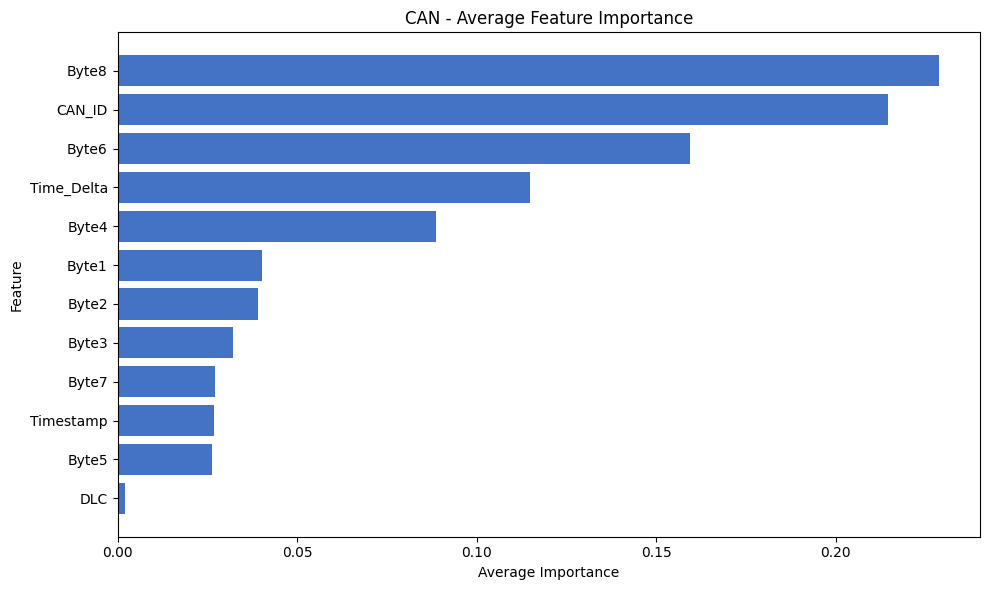

In [6]:
fig = plot_average_importance(importance_can, title='CAN - Average Feature Importance', top_n=20)
plt.show()


## CAN - Part 3: Gain Ratio


In [7]:
gain_ratio_can = compute_gain_ratio_all_features(can_bundle.x_train, can_bundle.y_train)
gain_ratio_can.to_csv(OUTPUT_DIR / 'CAN' / 'gain_ratio.csv')
display(gain_ratio_can.head(20))


c:\Users\KHOAZO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\KHOAZO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\KHOAZO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_discretizat

,gain_ratio
Byte3,0.161364
Byte5,0.153015
Byte2,0.142658
CAN_ID,0.124667
Byte8,0.124245
Time_Delta,0.122368
Byte4,0.115876
Byte1,0.112664
Byte6,0.102923
Timestamp,0.086560


## CAN - Part 4: CFS


In [8]:
cfs_features_can, cfs_score_can = cfs_forward_selection(
    can_bundle.x_train,
    can_bundle.y_train,
    max_features=min(20, can_bundle.x_train.shape[1]),
)

with open(OUTPUT_DIR / 'CAN' / 'cfs_features.txt', 'w', encoding='utf-8') as f:
    f.write(f'CFS merit: {cfs_score_can}\n')
    for feat in cfs_features_can:
        f.write(f'{feat}\n')

print('CFS CAN score:', cfs_score_can)
print('CFS CAN features:', cfs_features_can)


CFS CAN score: 0.3556202464002572
CFS CAN features: ['Time_Delta', 'Byte8', 'Timestamp', 'CAN_ID']


## CICIDS - Part 1: Train 4 models


In [9]:
models_cicids = train_tree_models(cicids_bundle.x_train, cicids_bundle.y_train)


Training DT ...
Training RF ...
Training ET ...
Training XGB ...


## CICIDS - Part 2: Average importance + selection + save main outputs


In [10]:
threshold_cicids = 0.9
importance_cicids = compute_average_importance(models_cicids, cicids_bundle.x_train.columns)
selected_features_cicids = select_features_by_threshold(importance_cicids, threshold=threshold_cicids)

X_train_CICIDS_selected, X_test_CICIDS_selected = map_selected_features(
    cicids_bundle.x_train,
    cicids_bundle.x_test,
    selected_features_cicids,
)

save_selection_outputs(
    out_dir=OUTPUT_DIR / 'CICIDS',
    x_train_selected=X_train_CICIDS_selected,
    x_test_selected=X_test_CICIDS_selected,
    selected_features=selected_features_cicids,
    threshold=threshold_cicids,
    dataset_name='CICIDS',
)

importance_cicids.to_csv(OUTPUT_DIR / 'CICIDS' / 'feature_importance.csv')

print('Selected CICIDS features:', selected_features_cicids)
display(importance_cicids.head(20))


Selected CICIDS features: ['Bwd Packet Length Std', 'Average Packet Size', 'Packet Length Std', 'PSH Flag Count', 'Fwd Packet Length Max', 'Bwd Packet Length Mean', 'Packet Length Variance', 'Destination Port', 'Idle Min', 'act_data_pkt_fwd', 'Avg Bwd Segment Size', 'Bwd Packets/s', 'Bwd Packet Length Max', 'Total Length of Fwd Packets', 'Max Packet Length', 'Packet Length Mean', 'Flow IAT Mean', 'Init_Win_bytes_forward', 'ACK Flag Count', 'Flow IAT Max', 'Idle Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Total Fwd Packets', 'Idle Max', 'Bwd Packet Length Min', 'Total Backward Packets', 'Flow IAT Std', 'Avg Fwd Segment Size', 'Init_Win_bytes_backward', 'Fwd Packet Length Mean', 'Total Length of Bwd Packets', 'Subflow Fwd Bytes']


,DT,RF,ET,XGB,avg_importance,cumulative
Bwd Packet Length Std,0.291286,0.050360,0.048401,0.177597,0.141911,0.141911
Average Packet Size,0.180969,0.044185,0.052528,0.073782,0.087866,0.229777
Packet Length Std,0.128528,0.059797,0.036871,0.000513,0.056427,0.286204
PSH Flag Count,0.010053,0.017241,0.079001,0.118155,0.056112,0.342317
Fwd Packet Length Max,0.122618,0.036503,0.010097,0.023255,0.048118,0.390435
Bwd Packet Length Mean,0.000001,0.041687,0.043825,0.094470,0.044996,0.435431
Packet Length Variance,0.000034,0.042148,0.039395,0.082937,0.041128,0.476559
Destination Port,0.102028,0.031649,0.019244,0.006788,0.039927,0.516487
Idle Min,0.000000,0.018548,0.039097,0.069772,0.031854,0.548341
act_data_pkt_fwd,0.000013,0.020520,0.003449,0.093377,0.029340,0.577680


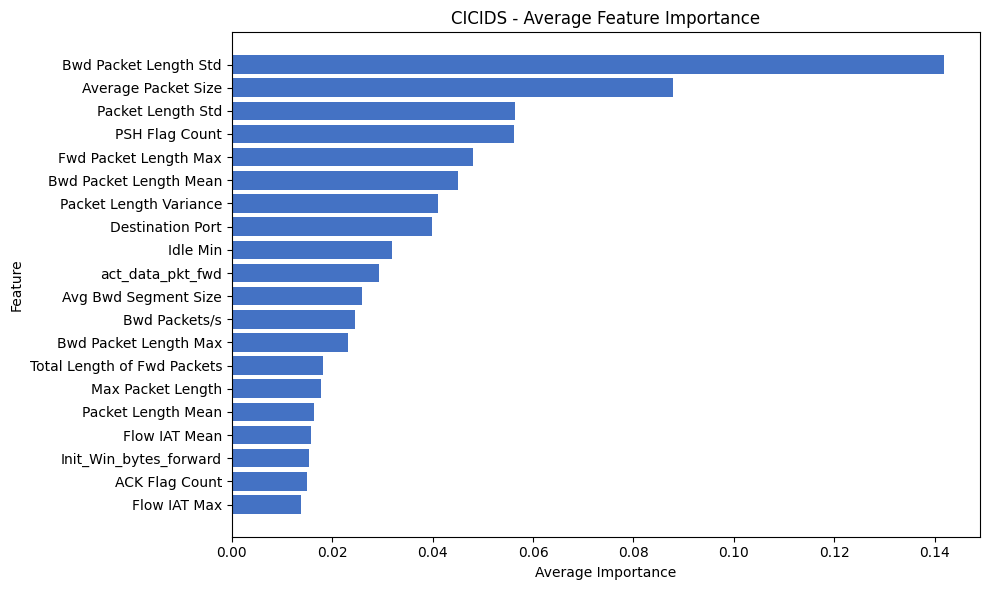

In [11]:
fig = plot_average_importance(importance_cicids, title='CICIDS - Average Feature Importance', top_n=20)
plt.show()


## CICIDS - Part 3: Gain Ratio


In [12]:
gain_ratio_cicids = compute_gain_ratio_all_features(cicids_bundle.x_train, cicids_bundle.y_train)
gain_ratio_cicids.to_csv(OUTPUT_DIR / 'CICIDS' / 'gain_ratio.csv')
display(gain_ratio_cicids.head(20))


c:\Users\KHOAZO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\KHOAZO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
c:\Users\KHOAZO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally 

,gain_ratio
Bwd Packet Length Std,0.289212
Init_Win_bytes_backward,0.228510
FIN Flag Count,0.220915
Destination Port,0.201001
Bwd Packet Length Mean,0.173285
Avg Bwd Segment Size,0.173278
Idle Max,0.169626
Idle Mean,0.169485
Bwd Packet Length Max,0.166431
Idle Min,0.165765


## CICIDS - Part 4: CFS


In [13]:
cfs_features_cicids, cfs_score_cicids = cfs_forward_selection(
    cicids_bundle.x_train,
    cicids_bundle.y_train,
    max_features=min(20, cicids_bundle.x_train.shape[1]),
)

with open(OUTPUT_DIR / 'CICIDS' / 'cfs_features.txt', 'w', encoding='utf-8') as f:
    f.write(f'CFS merit: {cfs_score_cicids}\n')
    for feat in cfs_features_cicids:
        f.write(f'{feat}\n')

print('CFS CICIDS score:', cfs_score_cicids)
print('CFS CICIDS features:', cfs_features_cicids)


CFS CICIDS score: 0.365834035735766
CFS CICIDS features: ['PSH Flag Count', 'Fwd IAT Std', 'Min Packet Length', 'Bwd Packets/s']


## Output Files

Moi dataset se co 3 file output chinh:
- `X_train_selected.csv`
- `X_test_selected.csv`
- `selected_features_list.txt`

Va 3 file phu:
- `feature_importance.csv`
- `gain_ratio.csv`
- `cfs_features.txt`
